In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, TotalExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense
from src.visualization import generate_linear_regression_from_lists

In [2]:
cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
advertising_efficiency_model = AdvertisingEfficiencyModel()
free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()
roi_model = RoiModel()

advertising_budget = AdvertisingCost(min_value=10000, max_value=30000)
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=6.8, min_value=6.0, max_value=7.5)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)
conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
cpa = CostPerAcquisition(min_value=12, max_value=36)
expense = Expense(0)

In [3]:
variables = {variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
             variable_names.DEAL_ORDERS: orders,
             variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
             variable_names.COST_ADVERTISING: advertising_budget,
             variable_names.COST_CONVERSION_RATE: conversion_rate,
             variable_names.COST_CPA: cpa,
             variable_names.DEAL_SELLING_PRICE: selling_price,
             variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

expected_result = evaluate_expected_scenario(variables=variables, model_pipeline=[advertising_efficiency_model, cogs_model,
                                                                revenue_model, cost_model, expense_model,
                                                                depreciation_model, net_income_model,
                                                                capital_expenditure_model, profit_model])
print(expected_result[variable_names.PROFIT])

1263823.5294117648


In [4]:
expected_result = evaluate_expected_scenario(variables=variables,
                                             model_pipeline=[cogs_model,
                                                             revenue_model, cost_model, advertising_efficiency_model, expense_model,
                                                             depreciation_model, net_income_model,
                                                             capital_expenditure_model, profit_model])
print(expected_result)

# Model topology error below:
# stochastic_bivariate_simulation(
#     variables=variables,
#     independent_target_x=variable_names.PROFIT,
#     dependent_target_y=variable_names.ROI,
#     shuffled_variables=[variable_names.DEAL_ORDERS,
#                         variable_names.DEAL_SELLING_PRICE,
#                         variable_names.DEAL_ITEMS_PER_ORDER],
#     model_pipeline=[cogs_model,
#                     revenue_model, cost_model,
#                     advertising_efficiency_model, expense_model,
#                     depreciation_model, net_income_model,
#                     capital_expenditure_model, profit_model],
#     sample_size=100)

{'PurchasingPrice': 1500.0, 'Orders': 14.705882352941178, 'USDToRMB': 6.8, 'AdvertisingCost': 20000.0, 'ConversionRate': 0.12000000000000001, 'CostPerAcquisition': 24.0, 'SellingPrice': 4500.0, 'ItemsPerOrder': 3.0, 'Cogs': 112500.0, 'Revenue': 2295000.0, 'Cost': 132500.0, 'Expense': 0.0, 'Depreciation': 0, 'NetIncome': 2162500.0, 'CapitalExpenditure': 0, 'Profit': 2162500.0}


In [5]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.PROFIT,
    dependent_target_y=variable_names.ROI,
    shuffled_variables=[variable_names.DEAL_ORDERS,
                        variable_names.DEAL_SELLING_PRICE,
                        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[cogs_model, revenue_model, cost_model, expense_model,
                    depreciation_model, net_income_model,
                    capital_expenditure_model, profit_model, roi_model],
    sample_size=100)

# print(linear_trend_summary)
print(simulated_x_distribution)
# print(simulated_y_distribution)

[1460261.2400537727, 2816008.9795535346, 2385730.52162381, 906116.3044675809, 4179749.6191918417, 685808.3234040929, 3215601.1977505987, 1893646.313025936, 1720760.6457665293, 3380269.2178251976, 1432859.645145384, 1463947.8476215943, 3992863.34887909, 886407.7200583352, 1725061.6322981385, 1122547.0870910678, 2284895.5977670355, 973033.8213121451, 3144256.204062452, 1481239.8910766318, 3324518.872204355, 1421658.8589215542, 917233.0228446893, 3949084.5232297857, 874499.828928574, 3476386.614464637, 2288681.2019148413, 3936346.318982716, 3358938.9861432407, 588864.2525091193, 691438.5510274669, 2242285.1284904056, 2023620.7600375644, 2774968.154175581, 3105314.239789168, 2708257.514583683, 4105470.7212133827, 1303822.2590290308, 2000083.3007643467, 3354739.790207842, 1572640.3252980893, 1186005.4758989366, 2515375.9610942, 1174503.3935395635, 1681741.747879075, 2768503.1205430957, 467114.29408054095, 2847725.008923776, 438709.8200329166, 2381597.986642395, 2899098.5813512355, 2803787.8

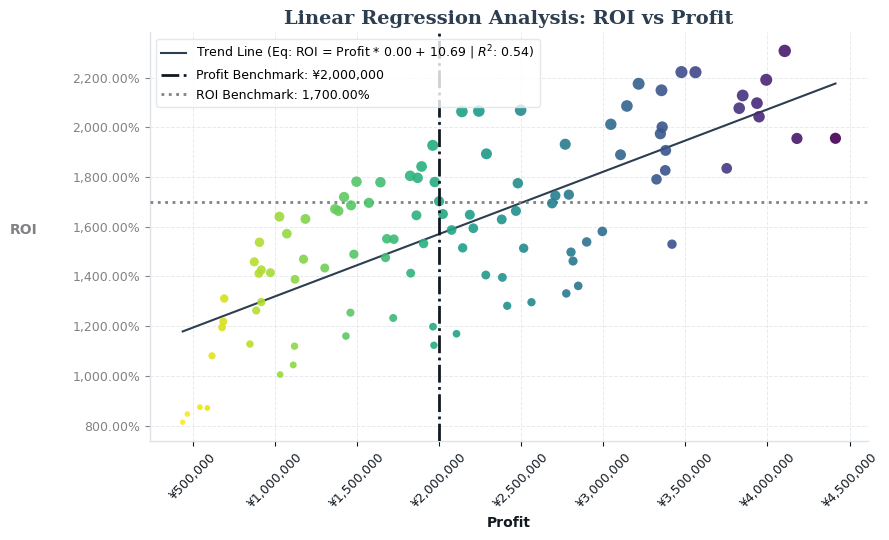

In [6]:
fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.PROFIT, variable_names.ROI,
                                           x_benchmark=2000000, y_benchmark=17)
plt.show()

In [7]:
variables_2 = {variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
               variable_names.DEAL_SELLING_PRICE: selling_price,
               variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
               variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
               variable_names.COST_ADVERTISING: advertising_budget,
               variable_names.COST_CPA: cpa,
               variable_names.COST_CONVERSION_RATE: conversion_rate,
               variable_names.EXPENSE: expense}

simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables_2,
    independent_target_x=variable_names.COST_ADVERTISING,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[
        variable_names.COST_ADVERTISING,
        variable_names.DEAL_SELLING_PRICE,
        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[advertising_efficiency_model, cogs_model, revenue_model, cost_model,
                    depreciation_model, capital_expenditure_model,
                    net_income_model, profit_model, roi_model],
    sample_size=100)

print(linear_trend_summary)

{'slope': 66.40345743348188, 'intercept': -86113.9233266327, 'r_squared': 0.3084863318220333, 'p_value': 2.00256697950291e-09, 'standard_error': 10.042921675601006}


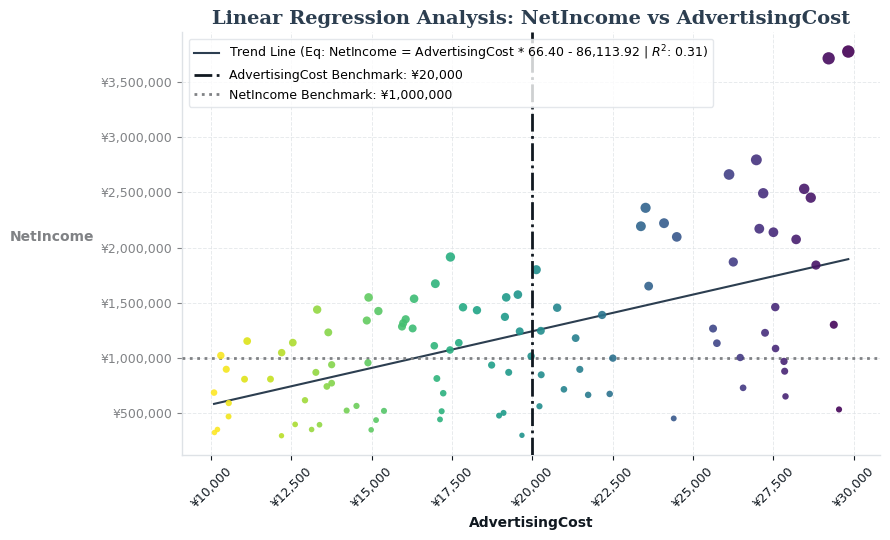

In [8]:
fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.COST_ADVERTISING, variable_names.NET_INCOME,
                                            x_benchmark=20000, y_benchmark=1000000)
plt.show()